# Customer Churn Dataset Exploration

Columns:
- customerId: Customer ID
- gender: Male or Female
- SeniorCitizen: Whether the customer is a senior citizen or not (1, 0)
- Partner: Whether the customer has a partner or not (Yes, No)
- Dependents: Whether the customer has dependents or not (Yes, No)
- tenure: Number of months the customer has stayed with the company
- PhoneService: Whether the customer has a phone service or not (Yes, No)
- MultipleLines: Whether the customer has multiple lines or not (Yes, No, No phone service)
- InternetService: Customer’s internet service provider (DSL, Fiber optic, No)
- OnlineSecurity: Whether the customer has online security or not (Yes, No, No internet service)
- OnlineBackup: Whether the customer has online backup or not (Yes, No, No internet service)
- DeviceProtection: Whether the customer has device protection or not (Yes, No, No internet service)
- TechSupport: Whether the customer has tech support or not (Yes, No, No internet service)
- StreamingTV: Whether the customer has streaming TV or not (Yes, No, No internet service)
- StreamingMovies: Whether the customer has streaming movies or not (Yes, No, No internet service)
- Contract: The contract term of the customer (Month-to-month, One year, Two year)
- PaperlessBilling: Whether the customer has paperless billing or not (Yes, No)
- PaymentMethod: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card
- MonthlyCharges: The amount charged to the customer monthly
- TotalCharges: The total amount charged to the customer
- Churn: Whether the customer churned or not (Yes or No)


In [1]:
import pandas as pd

df = pd.read_csv(r"C:\dev\customer-churn\data\raw\customer-churn-dataset.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Dataset basic info

In [2]:
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns}")
print(f"\nDataset types: \n{df.dtypes}")
print(f"\nDataset null values: \n{df.isnull().sum()}")
print(f"\nDataset empty values: \n{df.astype(str).apply(lambda col: col.str.strip().eq('').sum())}")

Dataset shape: (7043, 21)

Dataset columns: Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset types: 
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         objec

In [3]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"\nDataset null values after conversion: \n{df['TotalCharges'].isnull().sum()}")


Dataset null values after conversion: 
11


In [4]:
# Remove rows with null values in 'TotalCharges'
df = df.dropna(subset=['TotalCharges'])

print(f"\nDataset shape after removing null 'TotalCharges': {df.shape}")


Dataset shape after removing null 'TotalCharges': (7032, 21)


In [5]:
print("Churn value counts:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

Churn value counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


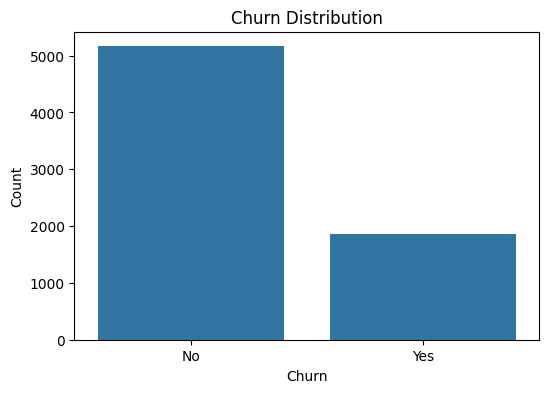

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='Churn', data=df)

plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

plt.show()

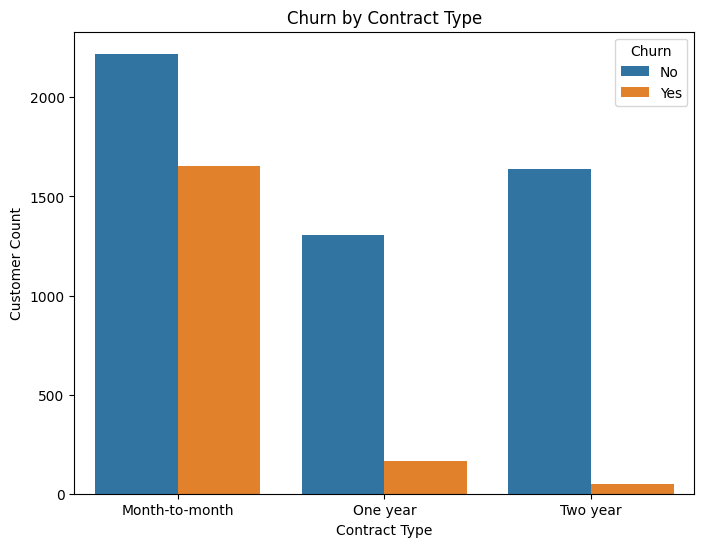

In [7]:
# Check churn by contract type

plt.figure(figsize=(8, 6))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.legend(title='Churn')

plt.show()

Analyzing the chart, we can see that the majority if customer churn comes from those with Month-to-Month contrat type

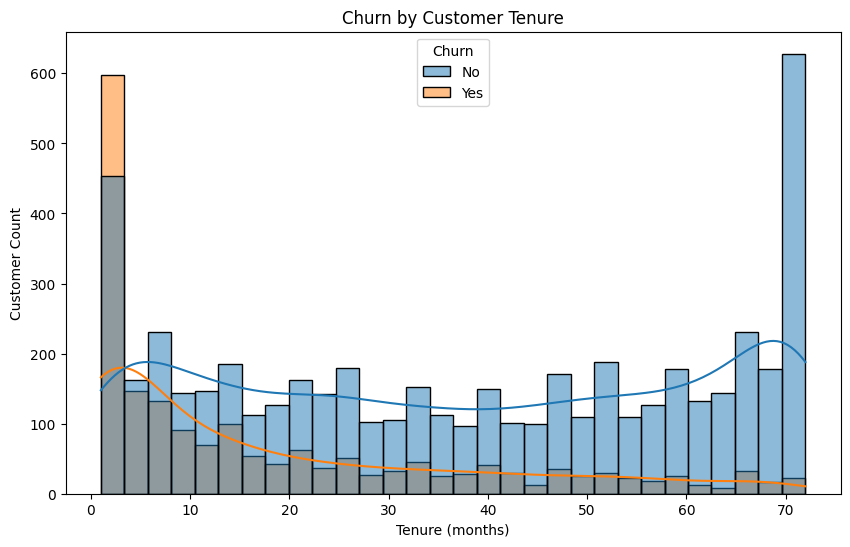

In [8]:
# Churn by customer tenure

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)

plt.title('Churn by Customer Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Customer Count')

plt.show()

Customers with shorter tenure are more likely to churn

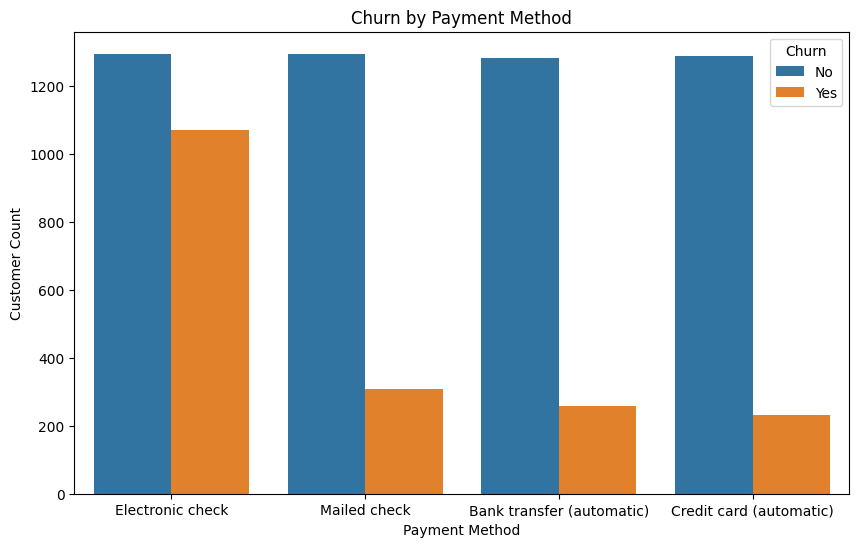

In [9]:
# Check churn by payment method

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')

plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')

plt.show()

In [10]:
df.groupby(['PaymentMethod', 'Churn']).size()

PaymentMethod              Churn
Bank transfer (automatic)  No       1284
                           Yes       258
Credit card (automatic)    No       1289
                           Yes       232
Electronic check           No       1294
                           Yes      1071
Mailed check               No       1296
                           Yes       308
dtype: int64

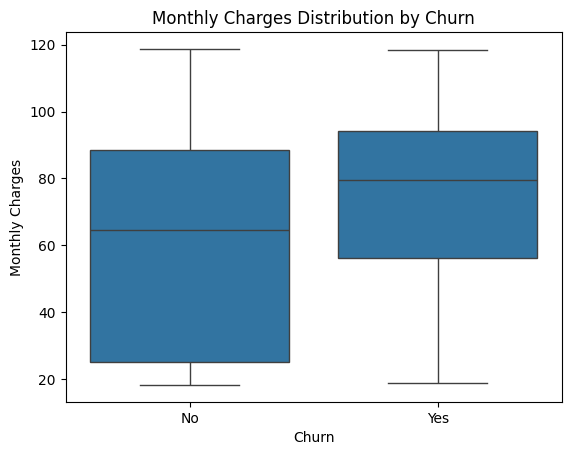

In [12]:
# Monthly charges distribution by churn

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

In [14]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


Customers who chuned have, on average, higher monthly charges. And the no churn group has paying customers ranging from very low to high amounts, whereas the yes group is more concentrated on relatively high charges

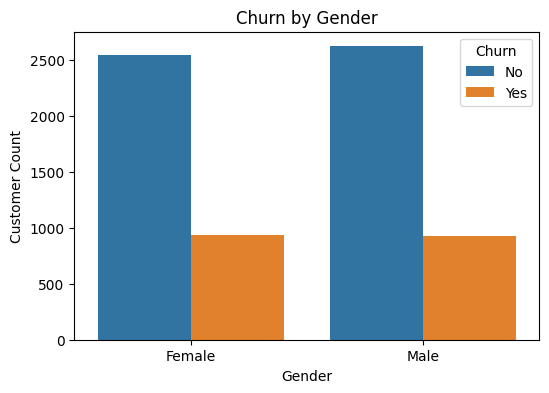

In [16]:
# Churn by gender

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='gender', hue='Churn')

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Customer Count')

plt.show()

The churn distribution by gender is quite similar

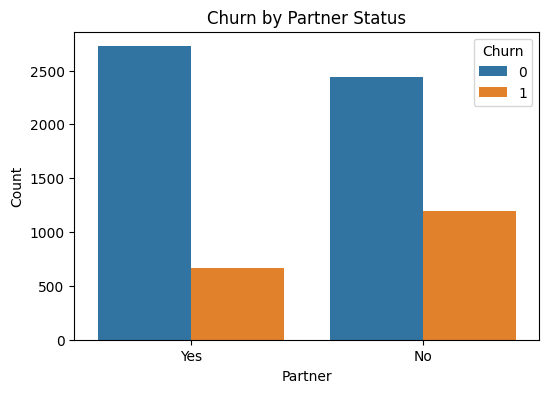

In [19]:
# Churn by partner status

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Partner', hue='Churn')

plt.title('Churn by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Count')

plt.show()

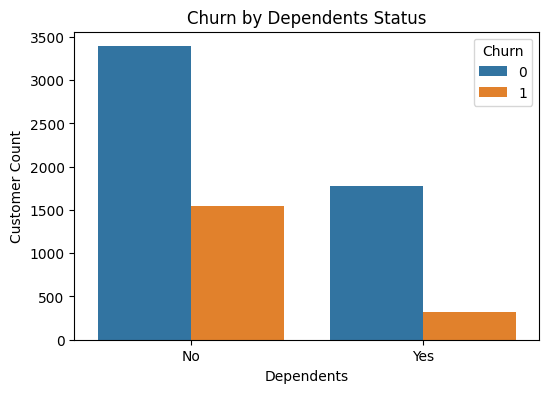

In [20]:
# Churn by dependents status

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Dependents', hue='Churn')

plt.title('Churn by Dependents Status')
plt.xlabel('Dependents')
plt.ylabel('Customer Count')

plt.show()

In [21]:
categorical_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

for col in categorical_cols:
    print(f'\n--- {col} ---')
    print(df.groupby(col)['Churn'].mean().sort_values(ascending=False))


--- gender ---
gender
Female    0.269595
Male      0.262046
Name: Churn, dtype: float64

--- Partner ---
Partner
No     0.329761
Yes    0.197171
Name: Churn, dtype: float64

--- Dependents ---
Dependents
No     0.312791
Yes    0.155312
Name: Churn, dtype: float64

--- PhoneService ---
PhoneService
Yes    0.267475
No     0.250000
Name: Churn, dtype: float64

--- MultipleLines ---
MultipleLines
Yes                 0.286485
No                  0.250812
No phone service    0.250000
Name: Churn, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Churn, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.417787
Yes                    0.146402
No internet service    0.074342
Name: Churn, dtype: float64

--- OnlineBackup ---
OnlineBackup
No                     0.399417
Yes                    0.215670
No internet service    0.074342
Name: Churn, dtype: float64

--- DeviceProtection ---

In [22]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [23]:
df.groupby('Contract')['MonthlyCharges'].mean()

Contract
Month-to-month    66.398490
One year          65.079416
Two year          60.872374
Name: MonthlyCharges, dtype: float64

In [18]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

corr = df.corr(numeric_only=True)['Churn'].sort_values()

print(corr)

tenure           -0.354049
TotalCharges     -0.199484
SeniorCitizen     0.150541
MonthlyCharges    0.192858
Churn             1.000000
Name: Churn, dtype: float64
